In [85]:
""" Class 16. Data, Model and Training Pipeline for Deep Learning

Objectives:
1. Develop a data processing pipeline
2. Use torch builtin layers to create a deep feed forward neural network
3. Training techniques: checkpointing, training, evaluation, learning rate scheduling
"""

import torch
from torchvision import transforms
import pandas as pd
import os
import torch.nn as nn

In [86]:
""" Machine Learning workflow
1. Data Processing 
2. Model Creation
3. Training
4. Evaluation
5. Deployment 
6. Monitoring
"""

ROOT_DIR = "E:\\PyCharmProjects\\pythonProject\\"
DATA_DIR = os.path.join(ROOT_DIR, "data")

In [87]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [88]:
dataset_path = os.path.join(DATA_DIR, "digit_train.csv")

In [89]:
data = pd.read_csv(dataset_path)
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [90]:
"""
Pixels 784
Label 1
"""
len(data.columns)

785

In [91]:
idx = 3
pixels = data.iloc[idx].values[1:].astype('float32')
label = data.iloc[idx].values[0]
print(pixels.shape, label)

(784,) 4


In [92]:
print(type(pixels))
print(type(label))

<class 'numpy.ndarray'>
<class 'numpy.int64'>


In [93]:
pixels = torch.tensor(pixels)
label = torch.tensor(label)
print(pixels[210:230])
print(label)

tensor([  0.,   0.,   0.,  27., 254.,  63.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.])
tensor(4)


In [94]:
"""
Each image has three properties: channel, height, width
Channel x H x W

Grayscale: No of channels is 1
RGB: No of channels is 3
"""
pixels = pixels.reshape(28, 28).unsqueeze(0)
pixels.shape

torch.Size([1, 28, 28])

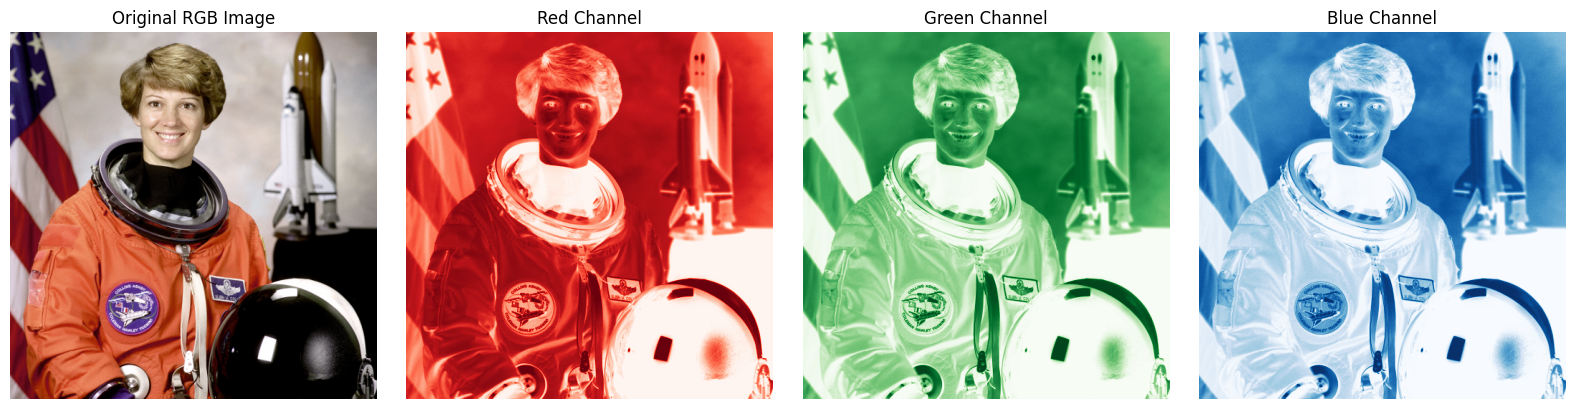

In [95]:
import matplotlib.pyplot as plt
from skimage import data

# Load a built-in RGB image
img = data.astronaut()

# Split into R, G, B channels
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

# Display the original and the separated channels
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

axs[0].imshow(img)
axs[0].set_title('Original RGB Image')
axs[0].axis('off')

axs[1].imshow(R, cmap='Reds')  # Use colored cmap for better visual distinction
axs[1].set_title('Red Channel')
axs[1].axis('off')

axs[2].imshow(G, cmap='Greens')
axs[2].set_title('Green Channel')
axs[2].axis('off')

axs[3].imshow(B, cmap='Blues')
axs[3].set_title('Blue Channel')
axs[3].axis('off')

plt.tight_layout()
plt.show()

In [96]:
pixels_transformation = transforms.Compose([
    transforms.Normalize(
        mean=torch.tensor([0.1307]), 
        std=torch.tensor([0.3081])),
])
pixels = pixels_transformation(pixels)

In [97]:
""" 
How to process a single example

pixels, label = example
converts them into tensor
pixels reshape into image
pixel transformation
"""

' \nHow to process a single example\n\npixels, label = example\nconverts them into tensor\npixels reshape into image\npixel transformation\n'

In [98]:
""" Dataset Class """
from torch.utils.data import Dataset

class DigitDataset(Dataset):
    def __init__(self, filepath, transform):
        self.data = pd.read_csv(filepath)
        self.transform = transform
    
    def __len__(self):
        """returns the total number of examples in the dataset """
        return len(self.data)
    
    def __getitem__(self, idx):
        """Process a single example in the dataset """
        pixels = self.data.iloc[idx].values[1:].astype('float32')
        label = int(self.data.iloc[idx].values[0])

        pixels = torch.tensor(pixels)
        label = torch.tensor(label)

        pixels = pixels.reshape(28, 28).unsqueeze(0) / 255.0
        if self.transform:
            pixels = pixels_transformation(pixels)

        # return pixels, label
    
        return {
            'pixels': pixels,
            'label': label,
            'date': '01-01-2026'
        }
        

In [99]:
dataset = DigitDataset(
    dataset_path,
    pixels_transformation
)

In [100]:
from torch.utils.data import random_split

torch.manual_seed(42)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset=dataset, 
    lengths=[train_size, val_size, test_size],
)

In [101]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = 32,
    shuffle = True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size = 64,
    shuffle = False
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size=16,
    shuffle = False
)

In [102]:
""" 
batch_idx = [3, 2, 1]
"""
for batch in train_loader:
    print(type(batch))
    print(batch.keys())
    pixels = batch['pixels']
    labels = batch['label']
    dates = batch['date']
    print(pixels.shape)
    print(labels.shape)
    print(labels)
    break

<class 'dict'>
dict_keys(['pixels', 'label', 'date'])
torch.Size([32, 1, 28, 28])
torch.Size([32])
tensor([6, 0, 0, 1, 7, 7, 1, 4, 0, 2, 1, 1, 5, 9, 2, 4, 3, 8, 6, 7, 2, 4, 1, 7,
        1, 7, 9, 5, 3, 2, 5, 0])


In [103]:
"""
dataset: __len__, __getitem__
dataloader: dataset, batch_size=2, shuffle

n = dataset.__len__() # let us assume there are 7 examples
batch_indices = [1, 0, 3, 2, 6, 4, 5] # index value of the examples
batch_indices = [[1, 0], # batch 1
                 [3, 2], # batch 2
                 [6, 4]  # batch 3
                 [5]]    # batch 4

processed_data = {
    'pixels': [],
    'label': [],
    'date': []
}

for idx in batch1:
   processed_example_dict = dataset.__getitem__(idx)
   processed_data['pixels'].append(processed_example_dict['pixels'])
   processed_data['label'].append(processed_example_dict['label'])
   processed_data['date'].append(processed_example_dict['date'])
   
return processed_data

for batch in train_loader:
    print(batch)
"""

class DigitClassifier(nn.Module):
    def __init__(self):
        super(DigitClassifier, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        # print('DEBUG:', type(x))
        # print('DEBUG:', x.shape)
        x = x.view(-1, 28 * 28)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        x = torch.relu(x)
        x = self.fc3(x)
        return x

In [104]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    val_loss = 0
    accuracy = 0
    with torch.no_grad():
        for batch_idx, batch in enumerate(data_loader):
            data = batch['pixels']
            target = batch['label']
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            val_loss += loss.item()
            
            _, predicted = torch.max(output.data, 1)
            accuracy += (predicted == target).sum().item()
        
        val_loss /= len(data_loader.dataset)
        accuracy /= len(data_loader.dataset)
    return val_loss, accuracy

In [105]:
def train_model(
        model, 
        train_loader, val_loader, 
        criterion, optimizer, 
        num_epochs, 
        device,
        checkpoint_path
):
    model.train()
    
    best_val_accuracy = 0
    patience = 3
    
    # Checkpoints
    checkpoint_dir = os.path.dirname(checkpoint_path)
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)
    
    for epoch in range(num_epochs):
        train_loss = 0
        for batch_idx, batch in enumerate(train_loader):
            pixel_batch = batch['pixels']
            label_batch = batch['label']
            pixel_batch, label_batch = pixel_batch.to(device), label_batch.to(device)
            
            optimizer.zero_grad()
            output = model(pixel_batch)
            loss = criterion(output, label_batch)
            loss.backward()
            optimizer.step()    
            train_loss += loss.item()
        train_loss /= len(train_loader.dataset) 
        val_loss, val_accuracy = evaluate_model(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            device=device
        )
        
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), checkpoint_path)
            print("Best parameter so far.")
        else:
            """ early stopping """
            patience = patience - 1
        
        print(f"epoch [{epoch+1}/{num_epochs}], loss: {train_loss:.4f}", end=" ")
        print(f"val_loss: {val_loss:.4f}", end=" ")
        print(f"val_acc: {val_accuracy:.4f}")
        
        if patience == 0:
            """ Callback: Early stopping """
            print(f"Model performance is not improving. Exiting the training.")
            break

In [106]:
model = DigitClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [107]:
checkpoint_path = os.path.join(
    os.getcwd(), "checkpoints", "best_model.pth"
)

In [108]:
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path))
    print("Model loaded successfully from checkpoints.")

In [109]:
train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=100,
    device=device,
    checkpoint_path=checkpoint_path,
)

Best parameter so far.
epoch [1/100], loss: 0.0101 val_loss: 0.0030 val_acc: 0.9421
Best parameter so far.
epoch [2/100], loss: 0.0045 val_loss: 0.0020 val_acc: 0.9590
Best parameter so far.
epoch [3/100], loss: 0.0031 val_loss: 0.0016 val_acc: 0.9679
epoch [4/100], loss: 0.0024 val_loss: 0.0018 val_acc: 0.9635
Best parameter so far.
epoch [5/100], loss: 0.0019 val_loss: 0.0014 val_acc: 0.9732
epoch [6/100], loss: 0.0015 val_loss: 0.0017 val_acc: 0.9694
epoch [7/100], loss: 0.0012 val_loss: 0.0015 val_acc: 0.9722
Model performance is not improving. Exiting the training.


In [111]:
model.load_state_dict(torch.load(checkpoint_path))

val_loss, val_acc = evaluate_model(
    model=model,
    data_loader=val_loader,
    criterion=criterion,
    device=device
)

print(f"val_loss: {val_loss:0.4f}, val_acc: {val_acc:0.4f}")

val_loss: 0.0014, val_acc: 0.9732


In [112]:
test_loss, test_accuracy = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

print(f"test_loss: {test_loss:0.4f}, test_acc: {test_accuracy:0.4f}")

test_loss: 0.0080, test_acc: 0.9641


# Bonus

In [114]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

X_train = np.array([data['pixels'].numpy().flatten() for data in train_dataset])
y_train = np.array([data['label'] for data in train_dataset])
X_test = np.array([data['pixels'].numpy().flatten() for data in test_dataset])
y_test = np.array([data['label'] for data in test_dataset])

dt_classifier = DecisionTreeClassifier()
dt_classifier.fit(X_train, y_train)

y_pred = dt_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'DecisionTreeClassifier test accuracy: {accuracy:.2f}')

DecisionTreeClassifier test accuracy: 0.85
